
# Q1. Line Structure Detection using LoG and Hough Transform

This notebook:
1. Loads an image containing prominent linear structures.
2. Converts it to grayscale.
3. Computes the **Laplacian of Gaussian (LoG)** response.
4. Obtains an edge map using **zero-crossing detection**.
5. Repeats zero-crossing detection with a threshold to suppress weak LoG responses.
6. Applies the **Hough Transform** for line detection.
7. Overlays detected lines on the original image.
8. Compares the two LoG threshold settings and discusses false detections.

> **Note:** Place your input image in the same directory as this notebook and set `IMAGE_PATH` below.


In [1]:

# Install/import required libraries
# If needed, uncomment the next line:
# !pip install opencv-python scikit-image matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.transform import hough_line, hough_line_peaks
from skimage.feature import canny

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["image.cmap"] = "gray"


In [ ]:

# -----------------------------
# Configuration
# -----------------------------
IMAGE_PATH = "../images/input_image1.png"   # <-- CHANGE THIS

# LoG parameters
GAUSSIAN_SIGMA = 1.4

# Zero-crossing thresholds
# 0.0 = use every sign change (weak responses included)
THRESHOLD_LOW = 0.0

# Increase this value to suppress weak LoG responses.
THRESHOLD_HIGH = 0.03

# Hough parameters
NUM_LINES = 20
MIN_DISTANCE = 20
MIN_ANGLE = 10


Image shape: (548, 1037, 3)


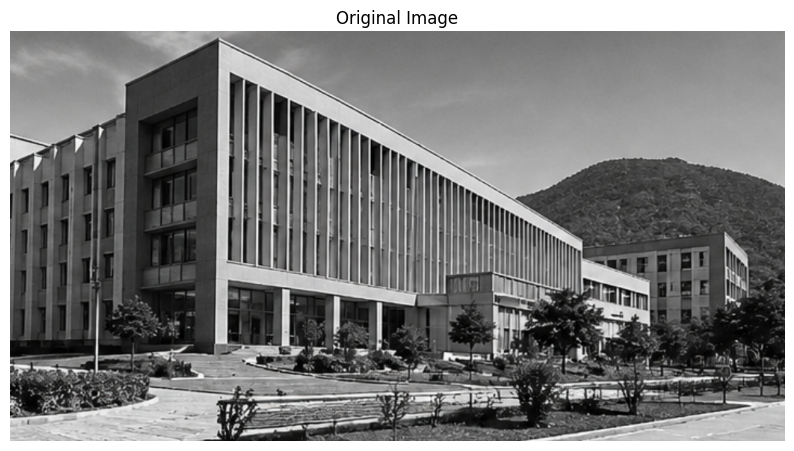

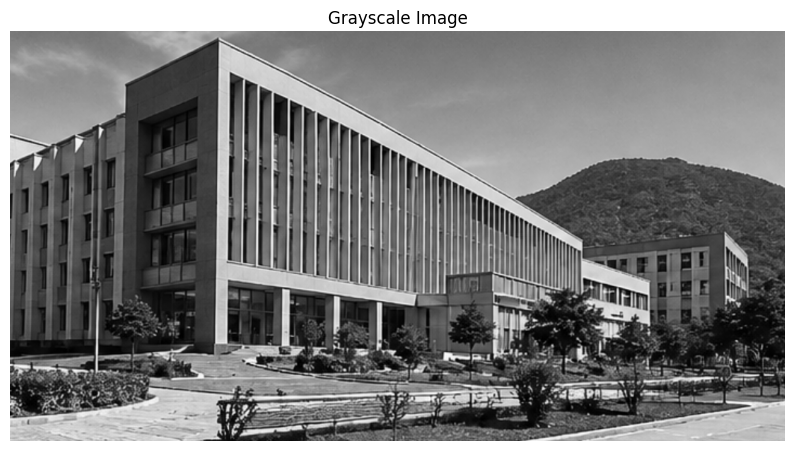

In [3]:

# Load image
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise FileNotFoundError(
        f"Could not read '{IMAGE_PATH}'. "
        "Place the image in the notebook directory or update IMAGE_PATH."
    )

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
gray_float = gray.astype(np.float32) / 255.0

print("Image shape:", image_rgb.shape)

plt.figure()
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()



## 1. Laplacian of Gaussian (LoG)

The image is first smoothed using a Gaussian filter and then the Laplacian is applied.

The LoG response highlights locations where the second spatial derivative changes sign. We use these **zero crossings** as candidate edges.


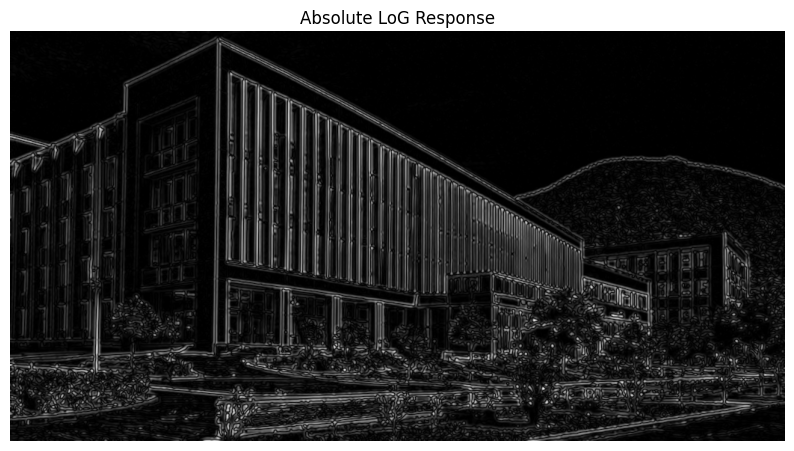

In [4]:

# Compute LoG response
blurred = cv2.GaussianBlur(
    gray_float,
    ksize=(0, 0),
    sigmaX=GAUSSIAN_SIGMA,
    sigmaY=GAUSSIAN_SIGMA
)

log_response = cv2.Laplacian(
    blurred,
    cv2.CV_32F,
    ksize=3
)

# Normalize only for visualization
log_vis = cv2.normalize(
    np.abs(log_response),
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure()
plt.imshow(log_vis, cmap="gray")
plt.title("Absolute LoG Response")
plt.axis("off")
plt.show()



## 2. Zero-crossing edge detection

A zero crossing occurs when neighboring LoG values have opposite signs.

For each pixel, we check its 8-neighborhood. An edge is detected when:
- the neighborhood contains both positive and negative values, and
- the magnitude of the LoG response is larger than the selected threshold.

Two cases are tested:
- **Threshold = 0:** weak zero crossings are retained.
- **Higher threshold:** weak LoG responses are suppressed.


In [5]:

def zero_crossing_edges(log_img, threshold=0.0):
    """Detect LoG zero crossings with a magnitude threshold."""

    h, w = log_img.shape

    # Pad so every pixel has an 8-neighborhood
    padded = np.pad(log_img, 1, mode="edge")

    center = padded[1:-1, 1:-1]

    neighborhood_values = []
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            neighborhood_values.append(
                padded[
                    1 + dr : 1 + dr + h,
                    1 + dc : 1 + dc + w
                ]
            )

    neighbors = np.stack(neighborhood_values, axis=0)

    has_positive = np.any(neighbors > 0, axis=0)
    has_negative = np.any(neighbors < 0, axis=0)

    # A sign change between the center/neighborhood.
    sign_change = (
        ((center > 0) & has_negative) |
        ((center < 0) & has_positive)
    )

    # Suppress weak LoG responses.
    magnitude = np.abs(center)
    strong_response = magnitude >= threshold

    edges = sign_change & strong_response

    return edges.astype(np.uint8) * 255


edges_low = zero_crossing_edges(log_response, THRESHOLD_LOW)
edges_high = zero_crossing_edges(log_response, THRESHOLD_HIGH)

print("Low-threshold edge pixels :", np.count_nonzero(edges_low))
print("High-threshold edge pixels:", np.count_nonzero(edges_high))


Low-threshold edge pixels : 372187
High-threshold edge pixels: 147559


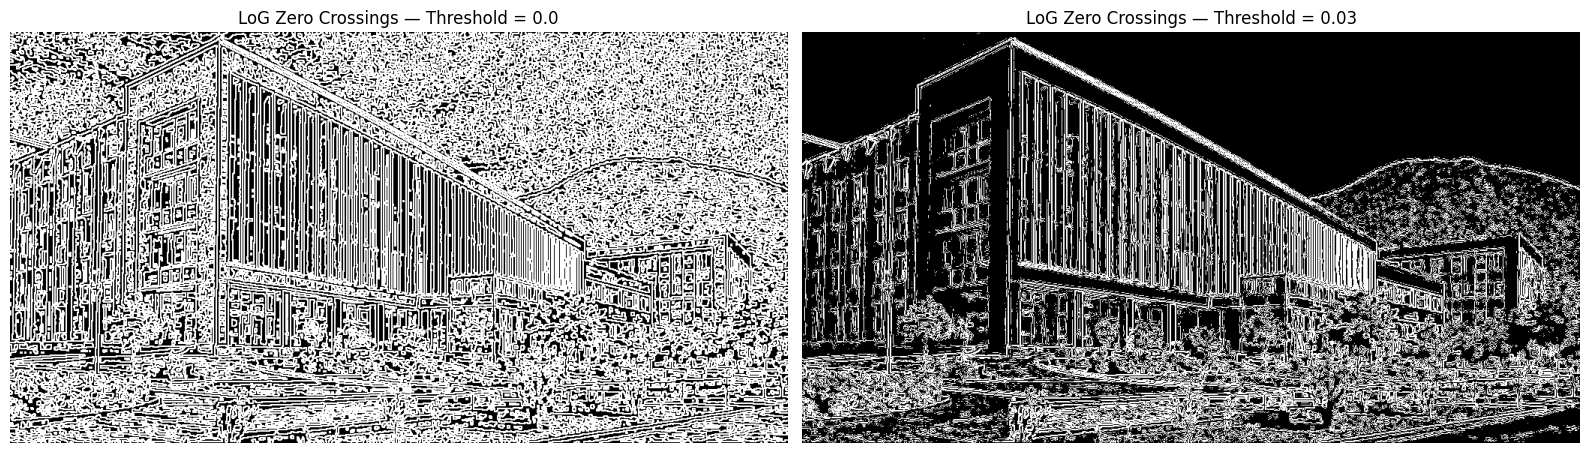

In [6]:

# Visualize the two LoG zero-crossing edge maps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(edges_low, cmap="gray")
axes[0].set_title(f"LoG Zero Crossings — Threshold = {THRESHOLD_LOW}")
axes[0].axis("off")

axes[1].imshow(edges_high, cmap="gray")
axes[1].set_title(f"LoG Zero Crossings — Threshold = {THRESHOLD_HIGH}")
axes[1].axis("off")

plt.tight_layout()
plt.show()



## 3. Hough Transform

The edge maps are supplied to the Hough line transform.

`hough_line` computes votes in the $(\rho, \theta)$ parameter space, where:

$$
\rho = x\cos(\theta) + y\sin(\theta)
$$

The strongest peaks correspond to prominent lines in the image.


In [7]:

def detect_hough_lines(edge_image, num_lines=20,
                       min_distance=20, min_angle=10):
    """Detect prominent Hough lines from a binary edge image."""

    # hough_line expects a boolean edge image
    hspace, angles, distances = hough_line(edge_image > 0)

    accum, peak_angles, peak_distances = hough_line_peaks(
        hspace,
        angles,
        distances,
        num_peaks=num_lines,
        min_distance=min_distance,
        min_angle=min_angle
    )

    return hspace, angles, distances, accum, peak_angles, peak_distances


hough_low = detect_hough_lines(
    edges_low,
    num_lines=NUM_LINES,
    min_distance=MIN_DISTANCE,
    min_angle=MIN_ANGLE
)

hough_high = detect_hough_lines(
    edges_high,
    num_lines=NUM_LINES,
    min_distance=MIN_DISTANCE,
    min_angle=MIN_ANGLE
)

_, _, _, accum_low, angles_low, distances_low = hough_low
_, _, _, accum_high, angles_high, distances_high = hough_high

print("Detected lines with low threshold :", len(angles_low))
print("Detected lines with high threshold:", len(angles_high))


Detected lines with low threshold : 20
Detected lines with high threshold: 20


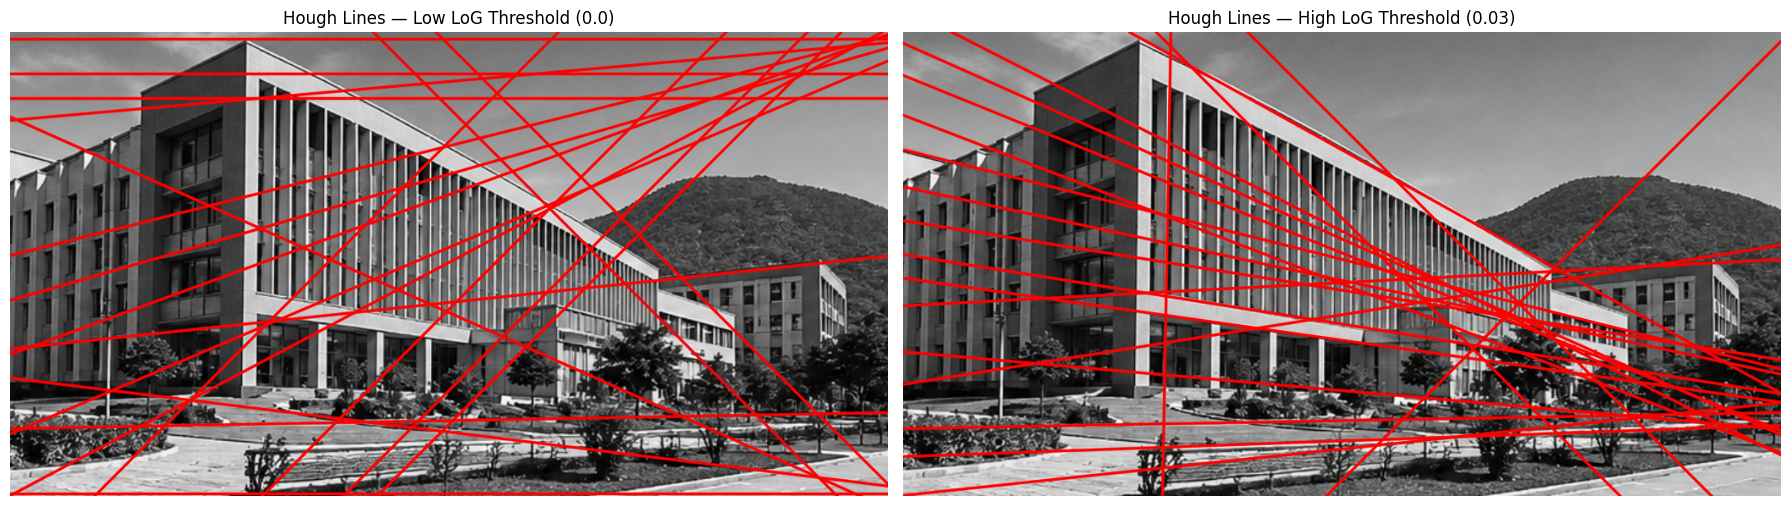

In [8]:

def overlay_hough_lines(image, angles, distances):
    """Draw infinite Hough lines across the image."""

    result = image.copy()
    h, w = image.shape[:2]

    for angle, distance in zip(angles, distances):
        # x*cos(theta) + y*sin(theta) = rho
        a = np.cos(angle)
        b = np.sin(angle)

        # One point on the line
        x0 = a * distance
        y0 = b * distance

        # Direction vector
        dx = -b
        dy = a

        # Make the line long enough to cross the whole image
        scale = max(h, w) * 2

        x1 = int(round(x0 + scale * dx))
        y1 = int(round(y0 + scale * dy))
        x2 = int(round(x0 - scale * dx))
        y2 = int(round(y0 - scale * dy))

        cv2.line(
            result,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

    return result


overlay_low = overlay_hough_lines(
    image_rgb,
    angles_low,
    distances_low
)

overlay_high = overlay_hough_lines(
    image_rgb,
    angles_high,
    distances_high
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(overlay_low)
axes[0].set_title(
    f"Hough Lines — Low LoG Threshold ({THRESHOLD_LOW})"
)
axes[0].axis("off")

axes[1].imshow(overlay_high)
axes[1].set_title(
    f"Hough Lines — High LoG Threshold ({THRESHOLD_HIGH})"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()



## 4. Hough accumulator comparison

The Hough accumulator shows how strongly different $(\rho, \theta)$ combinations are supported by the edge pixels.


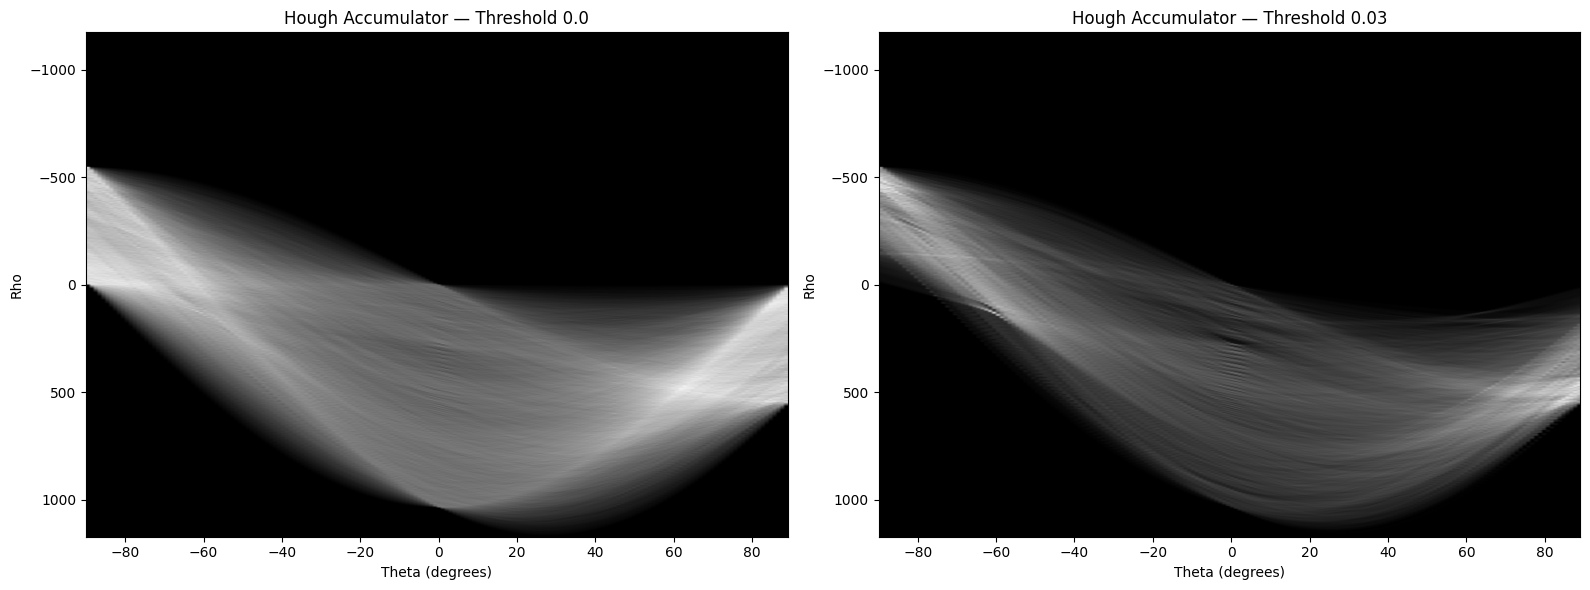

In [9]:

hspace_low, angles_grid_low, distances_grid_low, _, _, _ = hough_low
hspace_high, angles_grid_high, distances_grid_high, _, _, _ = hough_high

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(
    hspace_low,
    aspect="auto",
    extent=[
        np.rad2deg(angles_grid_low[0]),
        np.rad2deg(angles_grid_low[-1]),
        distances_grid_low[-1],
        distances_grid_low[0]
    ]
)
axes[0].set_title(f"Hough Accumulator — Threshold {THRESHOLD_LOW}")
axes[0].set_xlabel("Theta (degrees)")
axes[0].set_ylabel("Rho")

axes[1].imshow(
    hspace_high,
    aspect="auto",
    extent=[
        np.rad2deg(angles_grid_high[0]),
        np.rad2deg(angles_grid_high[-1]),
        distances_grid_high[-1],
        distances_grid_high[0]
    ]
)
axes[1].set_title(f"Hough Accumulator — Threshold {THRESHOLD_HIGH}")
axes[1].set_xlabel("Theta (degrees)")
axes[1].set_ylabel("Rho")

plt.tight_layout()
plt.show()



## 5. Quantitative comparison

The following table summarizes the number of edge pixels and Hough lines obtained under the two LoG threshold settings.


In [10]:

# Simple comparison table
print("=" * 60)
print("                 LoG Threshold Comparison")
print("=" * 60)
print(f"{'Measure':<35} {'Low':>10} {'High':>10}")
print("-" * 60)
print(f"{'LoG threshold':<35} {THRESHOLD_LOW:>10.4f} {THRESHOLD_HIGH:>10.4f}")
print(f"{'Edge pixels':<35} {np.count_nonzero(edges_low):>10} {np.count_nonzero(edges_high):>10}")
print(f"{'Hough lines detected':<35} {len(angles_low):>10} {len(angles_high):>10}")
print("=" * 60)


                 LoG Threshold Comparison
Measure                                    Low       High
------------------------------------------------------------
LoG threshold                           0.0000     0.0300
Edge pixels                             372187     147559
Hough lines detected                        20         20



## 6. Discussion

**Low LoG threshold:**  
Using a threshold close to zero preserves many zero crossings, including weak responses caused by texture, noise, illumination changes, and small structures. Consequently, the Hough Transform receives a denser edge map. This can produce more Hough peaks and a higher chance of false or irrelevant line detections.

**Higher LoG threshold:**  
Increasing the threshold suppresses weak LoG responses. The resulting edge map is usually cleaner and contains fewer edge pixels. This reduces spurious Hough votes and tends to emphasize stronger, more prominent linear structures.

**Trade-off:**  
If the threshold is too low, false detections increase. If it is too high, genuine but low-contrast lines can disappear. Therefore, the best threshold is image-dependent and should preserve the important structures while rejecting weak/noisy responses.

**Conclusion:**  
The Hough Transform itself is strongly affected by the quality of the LoG edge map. Threshold selection before Hough detection is therefore an important step in controlling the balance between **line sensitivity** and **false detections**.
